In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 자전거 데이터 캐글
https://www.kaggle.com/c/bike-sharing-demand/overview

In [5]:
# 데이터 불러오기
bike_df = pd.read_csv('data/bike_train.csv')#TODO:YOUR_CODE_HERE
bike_df.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
bike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB


In [6]:
# 문자열을 datetime 타입으로 변경.
bike_df['datetime'] = bike_df.datetime.apply(pd.to_datetime)

# datetime 타입에서 년, 월, 일, 시간 추출
# 년 추출 #TODO:YOUR_CODE_HERE
# 월 추출 #TODO:YOUR_CODE_HERE
# 일 추출 #TODO:YOUR_CODE_HERE
# 시간 추출 #TODO:YOUR_CODE_HERE
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [7]:
bike_df['month'] = bike_df['datetime'].dt.month
bike_df['hour'] = bike_df['datetime'].dt.hour
bike_df['dayofweek'] = bike_df['datetime'].dt.dayofweek
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,5


<Axes: >

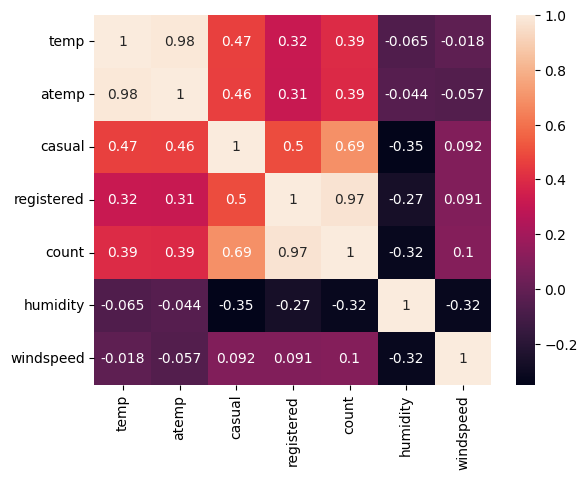

In [9]:
corr = bike_df[['temp','atemp', 'casual','registered',  'count','humidity', 'windspeed' ]].corr()
sns.heatmap(corr, annot=True)

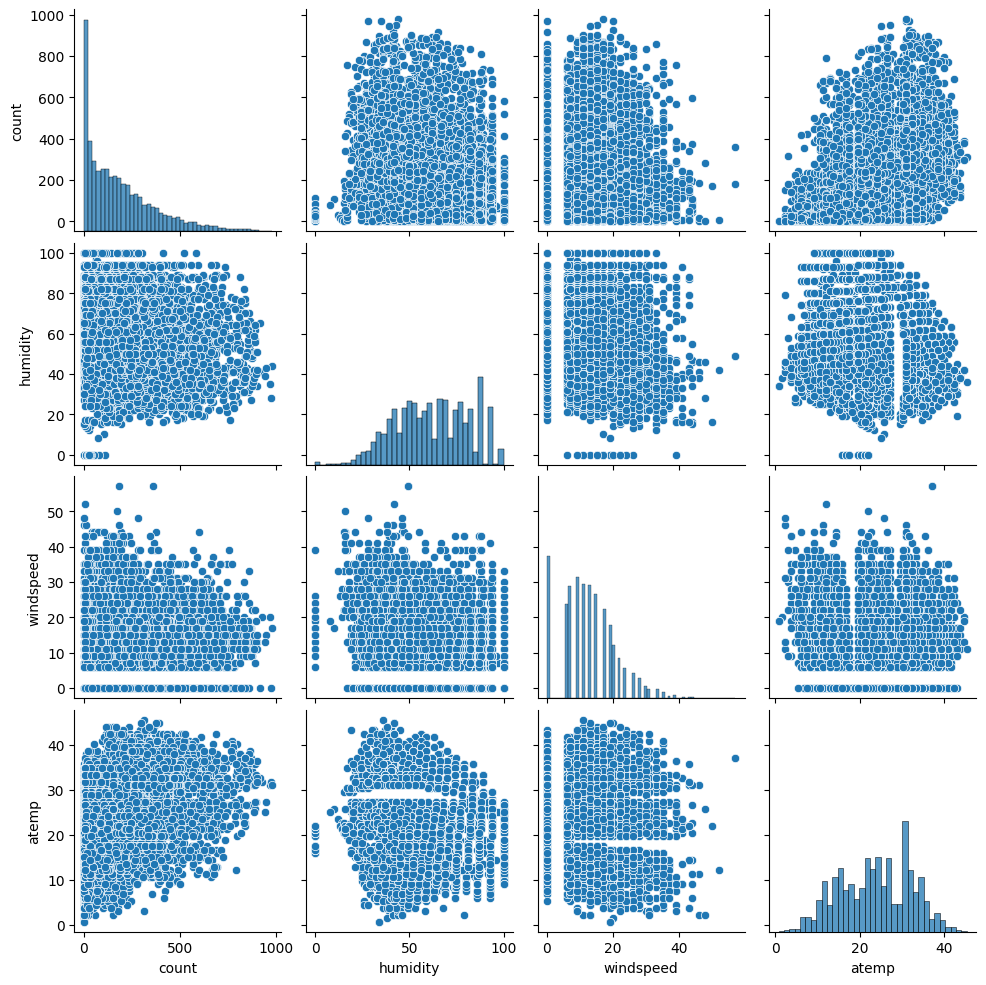

In [11]:
sns.pairplot(bike_df[['count','humidity', 'windspeed','atemp']])

In [ ]:
# 의미 도출 

In [7]:
bike_df.head(1)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,dayofweek
0,2011-01-01,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,5


In [12]:
# 변수선택 - 종속변수, 독립변수를 결정
X = bike_df[['season','holiday','workingday', 'weather','atemp', 'humidity', 'windspeed', 'month', 'hour', 'dayofweek']]
y = bike_df['count']

In [13]:
X

,season,holiday,workingday,weather,atemp,humidity,windspeed,month,hour,dayofweek
0,1,0,0,1,14.395,81,0.0000,1,0,5
1,1,0,0,1,13.635,80,0.0000,1,1,5
2,1,0,0,1,13.635,80,0.0000,1,2,5
3,1,0,0,1,14.395,75,0.0000,1,3,5
4,1,0,0,1,14.395,75,0.0000,1,4,5
...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,19.695,50,26.0027,12,19,2
10882,4,0,1,1,17.425,57,15.0013,12,20,2
10883,4,0,1,1,15.910,61,15.0013,12,21,2
10884,4,0,1,1,17.425,61,6.0032,12,22,2


In [ ]:
Data Fields
datetime - hourly date + timestamp  
season -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
holiday - whether the day is considered a holiday
workingday - whether the day is neither a weekend nor holiday
weather - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
temp - temperature in Celsius
atemp - "feels like" temperature in Celsius
humidity - relative humidity
windspeed - wind speed
casual - number of non-registered user rentals initiated
registered - number of registered user rentals initiated
count - number of total rentals

In [14]:
X.describe()

,season,holiday,workingday,weather,atemp,humidity,windspeed,month,hour,dayofweek
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,23.655084,61.886460,12.799395,6.521495,11.541613,3.013963
std,1.116174,0.166599,0.466159,0.633839,8.474601,19.245033,8.164537,3.444373,6.915838,2.004585
min,1.000000,0.000000,0.000000,1.000000,0.760000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,16.665000,47.000000,7.001500,4.000000,6.000000,1.000000
50%,3.000000,0.000000,1.000000,1.000000,24.240000,62.000000,12.998000,7.000000,12.000000,3.000000
75%,4.000000,0.000000,1.000000,2.000000,31.060000,77.000000,16.997900,10.000000,18.000000,5.000000
max,4.000000,1.000000,1.000000,4.000000,45.455000,100.000000,56.996900,12.000000,23.000000,6.000000


In [15]:
# 훈련세트/테스트세트 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7620, 10) (3266, 10) (7620,) (3266,)


In [16]:
# 모델 생성 및 훈련, MSE, R2 score

from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

LinearRegression()

In [18]:
pred = model.predict(X_test)

In [19]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

print(f'RMSE: {root_mean_squared_error(y_test, pred):.2f}') 
print(f'MSE: {mean_squared_error(y_test, pred):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test, pred):.2f}') # 결정계수(R2)

RMSE: 147.65
MSE: 21800.15
r2_score: 0.33


In [20]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predict': pred
})
result.head()

,Actual,Predict
3133,127,295.237963
5786,13,8.302959
5224,163,240.023193
8953,233,257.018808
8054,222,349.268750


In [21]:
result.sort_values(by='Predict').head()

,Actual,Predict
1020,4,-102.193064
409,7,-85.268871
5638,5,-81.766469
408,3,-81.664451
410,3,-77.511997


In [ ]:
# 수치형변수 스케일링 

In [22]:
# 범주형변수 원핫인코딩 
# cf_columns = ['season','weather','month', 'hour', 'dayofweek' , 'holiday', 'workingday' ]
cf_columns = ['season','weather','month', 'hour', 'dayofweek' ]
X_encoded = pd.get_dummies(X, columns=cf_columns)

In [23]:
X_encoded

,holiday,workingday,atemp,humidity,windspeed,season_1,season_2,season_3,season_4,weather_1,...,hour_21,hour_22,hour_23,dayofweek_0,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6
0,0,0,14.395,81,0.0000,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1,0,0,13.635,80,0.0000,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,0,0,13.635,80,0.0000,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,0,0,14.395,75,0.0000,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,0,0,14.395,75,0.0000,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,0,1,19.695,50,26.0027,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False
10882,0,1,17.425,57,15.0013,False,False,False,True,True,...,False,False,False,False,False,True,False,False,False,False
10883,0,1,15.910,61,15.0013,False,False,False,True,True,...,True,False,False,False,False,True,False,False,False,False
10884,0,1,17.425,61,6.0032,False,False,False,True,True,...,False,True,False,False,False,True,False,False,False,False


In [24]:
X_encoded_train, X_encoded_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state = 42)

In [25]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_encoded_train, y_train)
pred2 = model2.predict(X_encoded_test)

In [27]:
print(f'RMSE: {root_mean_squared_error(y_test, pred2):.2f}') 
print(f'MSE: {mean_squared_error(y_test, pred2):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test, pred2):.2f}') # 결정계수(R2)

RMSE: 111.57
MSE: 12447.80
r2_score: 0.62


In [ ]:
MSE: 21800.15
r2_score: 0.33

MSE: 12447.80
r2_score: 0.62

In [28]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predict': pred2
})
result.head()

,Actual,Predict
3133,127,279.0000
5786,13,-32.1875
5224,163,389.9375
8953,233,220.1875
8054,222,163.0000


In [32]:
result.sort_values(by='Predict').head() # , ascending=False

,Actual,Predict
411,2,-167.8750
457,1,-156.8750
410,3,-155.2500
409,7,-148.8125
1020,4,-145.4375


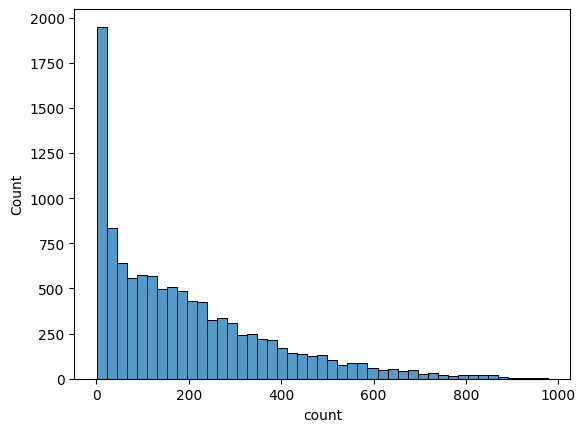

In [35]:
sns.histplot(y)
plt.show()

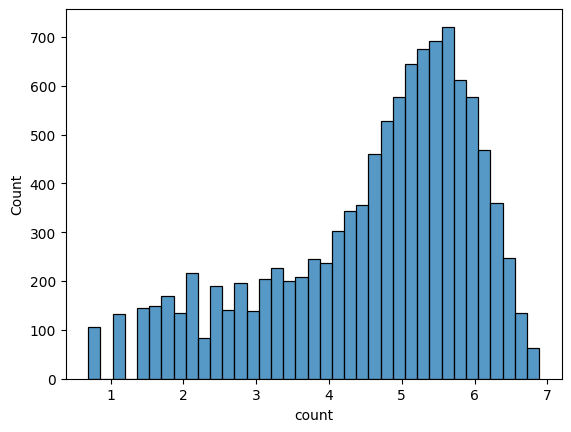

In [34]:
sns.histplot(np.log1p(y))
plt.show()

In [36]:
cf_columns = ['season','weather','month', 'hour', 'dayofweek' ]
X_encoded = pd.get_dummies(X, columns=cf_columns)

y_log = np.log1p(y)

X_encoded_train, X_encoded_test, y_log_train, y_log_test = train_test_split(X_encoded, y_log, test_size=0.3, random_state = 42)

model4 = LinearRegression()
model4.fit(X_encoded_train, y_log_train)
pred_log = model4.predict(X_encoded_test)

In [38]:
pred_actual = np.expm1(pred_log)
y_test_actual = np.expm1(y_log_test)

In [40]:
result = pd.DataFrame({
    'Actual': y_test_actual,
    'Predict': pred_actual
})
result.head()

,Actual,Predict
3133,127.0,266.424336
5786,13.0,24.246397
5224,163.0,319.725015
8953,233.0,197.638909
8054,222.0,123.567079


In [41]:
result.sort_values(by='Predict').head() # , ascending=False

,Actual,Predict
411,2.0,0.617696
5807,2.0,0.943795
5688,2.0,1.064460
5712,3.0,1.103316
457,1.0,1.434608


In [39]:
print(f'RMSE: {root_mean_squared_error(y_test_actual, pred_actual):.2f}') 
print(f'MSE: {mean_squared_error(y_test_actual, pred_actual):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test_actual, pred_actual):.2f}') # 결정계수(R2)

RMSE: 111.28
MSE: 12382.20
r2_score: 0.62


In [ ]:
RMSE: 111.57
MSE: 12447.80
r2_score: 0.62

In [ ]:
# 스케일러 
atemp, humidity, windspeed

# TODO: 스케일링을 적용해보시고 모델의 성능이 나아지는지 관찰
# 나아지지 않았다면 또 고려해볼 수 있는 사항 생각해보기!!!
# 결과 및 결론 산출물 파일에 정리하고 손들기!!!

In [ ]:
# 최종 훈련 테스트 데이터 만들어서 모델 생성 및 훈련

In [71]:
# 새로운 데이터 예측 하기 

new_row = {
    "season": 2, "holiday": 0, "workingday": 1, "weather": 1,
    "atemp": 20.5, "humidity": 55, "windspeed": 0.12,
    "year": 2025, "month": 5, "day": 1, "hour": 17, "dayofweek": 3
}

new_df = pd.DataFrame([new_row])


# print(f"예상 대여 수: {count_pred:.0f}대")